## REBCO Solenoid Geometry Sweep — Self-Consistent Je

This script performs a **2-D parametric sweep** over REBCO solenoid geometries, solving for a **self-consistent engineering current density** at each grid point, where the operating `Je` and the field-dependent critical current are brought into mutual equilibrium through fixed-point iteration.

---

### Geometry space

- **Inner radius** `Ri` : 10 mm → 1000 mm  (60 points, linear)
- **Winding thickness** `Th` : 10 mm → 100 mm  (60 points, linear)
- **Solenoid length** `L` : fixed at the value defined in `solenoid_lib`
- **Total grid** : 60 × 60 = 3 600 geometry configurations evaluated

---

### Self-consistent fixed point

Unlike the fixed-`Je` sweep, here `Je` is **not imposed** but **solved for** at each `(Ri, Th)` cell. The coupling between current density and field is resolved iteratively:

    Je  →  B0 = solenoid_field_center(Je)           (field rises with Je)
        →  Jc(B0)  from the empirical scaling law    (Jc falls as B0 rises)
        →  Je_new  = Jc(B0) × (1 − margin)           (derated operating point)
    iterate until  |Je_new − Je| / Je < tol_rel

This finds the operating point where the coil produces exactly the field that its tape can support at the prescribed margin. Loop controls:

| Parameter | Value | Meaning |
|---|---|---|
| `max_iter` | 50 | maximum iterations per cell |
| `tol_rel` | 1e-4 | relative convergence tolerance on `Je` |
| `je_init` | 500 A/mm² | initial guess (all cells) |

A per-cell convergence flag (`converged_grid2`) is stored, and the summary reports how many of the valid cells reached the tolerance.

---

### Physics computed at each grid point

For every converged `(Ri, Th)` pair the following quantities are recorded:

- **Central field** `B0` [T] — exact Biot-Savart analytical integral for a finite thick-walled solenoid, evaluated at the **self-consistent** `Je`
- **Self-consistent Je** `je_sc` [A/mm²] — the converged operating current density (the fixed point of the loop above)
- **Tape Jc** `je_crit` [A/mm²] — critical engineering current density of the REBCO tape at the operating field `B0`, from `Je_tape(B0, θ)`
- **Derated Je** `je_max` [A/mm²] — `je_crit × (1 − margin)`, the margin-limited operating ceiling (equals `je_sc` at convergence)
- **Load ratio** `Jc / Je_sc` [—] — should converge to `1 / (1 − margin)`, serving as a self-consistency sanity check
- **Hoop stress** `σ_hoop` [MPa] — thin-shell magnetic pressure approximation `σ = (B0² / 2µ0) × (Ri / Th)`
- **Scan rate** — figure of merit `(B0² × V_bore^(5/3))²`, stored in log₁₀ scale for plotting

---

### Output plots

All maps are on the `(Ri, Th)` plane in mm, with B0 iso-lines overlaid as dashed white lines for cross-reference:

1. **Central field B0** — self-consistent field at each geometry
2. **Self-consistent Je** — the converged operating current density
3. **Scan rate (log₁₀)** — identifies geometries that maximise the MRI figure of merit
4. **Hoop stress** — identifies mechanically overloaded regions
5. **Tape Jc** (`je_crit`) — tape current density ceiling at each operating point
6. **Combined map (Ri vs Th)** — B0, scan rate and hoop stress iso-lines overlaid
7. **Combined map (Ri vs A)** — same overlay on the `(Ri, conductor area)` plane, with thickness iso-lines as an orientation guide

---

### Key parameters

| Parameter | Value |
|---|---|
| Margin factor | 0.90 |
| Field angle `θ` | π/2 (B ∥ ab-plane, worst case) |
| Tape width | defined in `solenoid_lib` |
| Tape thickness | defined in `solenoid_lib` |

### Notes


  3600/3600  (100%)
2-D meshgrid computed.
  Valid cells        : 3600 / 3600
  Converged cells    : 3600 / 3600
  Ri                 : 10.0  –  1000.0 mm
  Th                 : 10.0  –  100.0 mm
  B0 (self-consist.) : 2.964  –  29.405 T
  Je (self-consist.) : 236.05  –  529.45 A/mm²
  Je_crit            : 2360.58  –  5294.51 A/mm²
  Je_max             : 236.06  –  529.45 A/mm²
  Load ratio         : 9.999  –  10.001
  Stress             : 13.4  –  1153.7 MPa
  V_bore             : 3.142e+02  –  3.142e+06 cm³


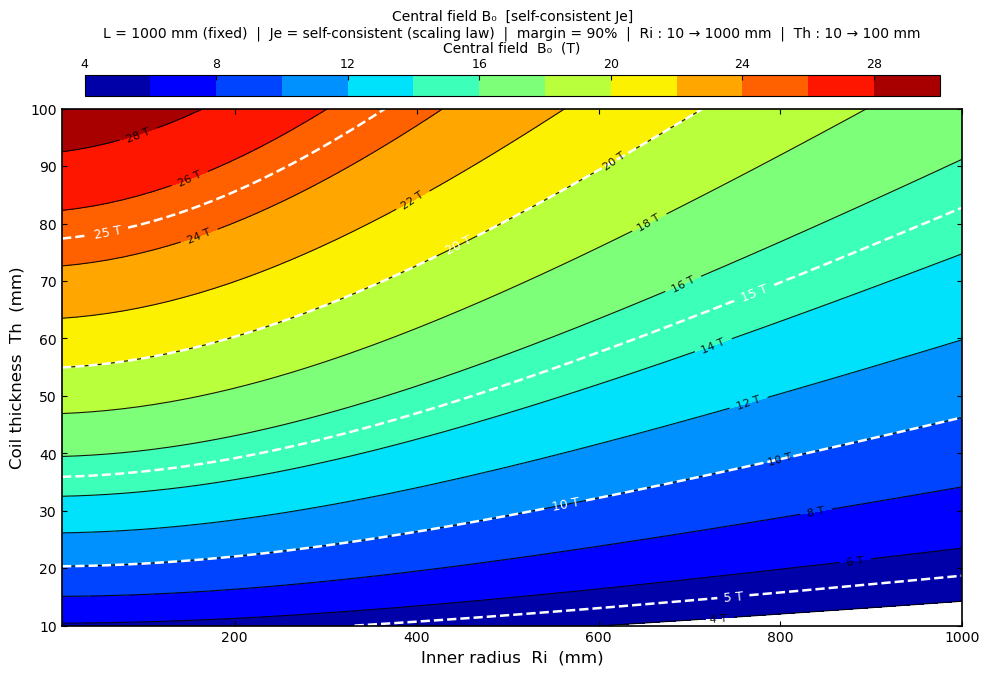

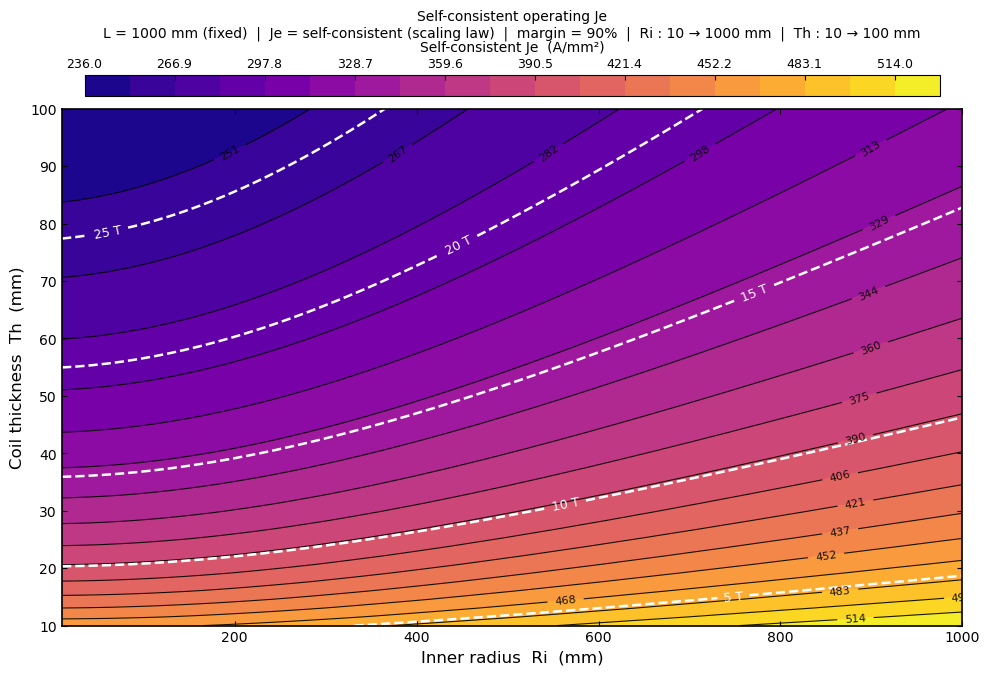

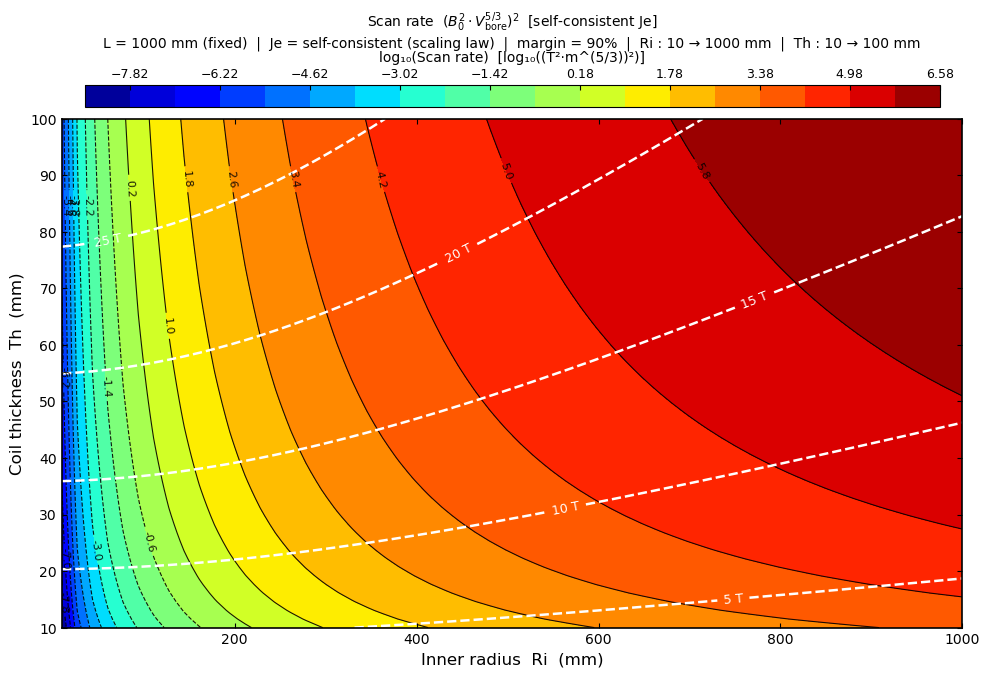

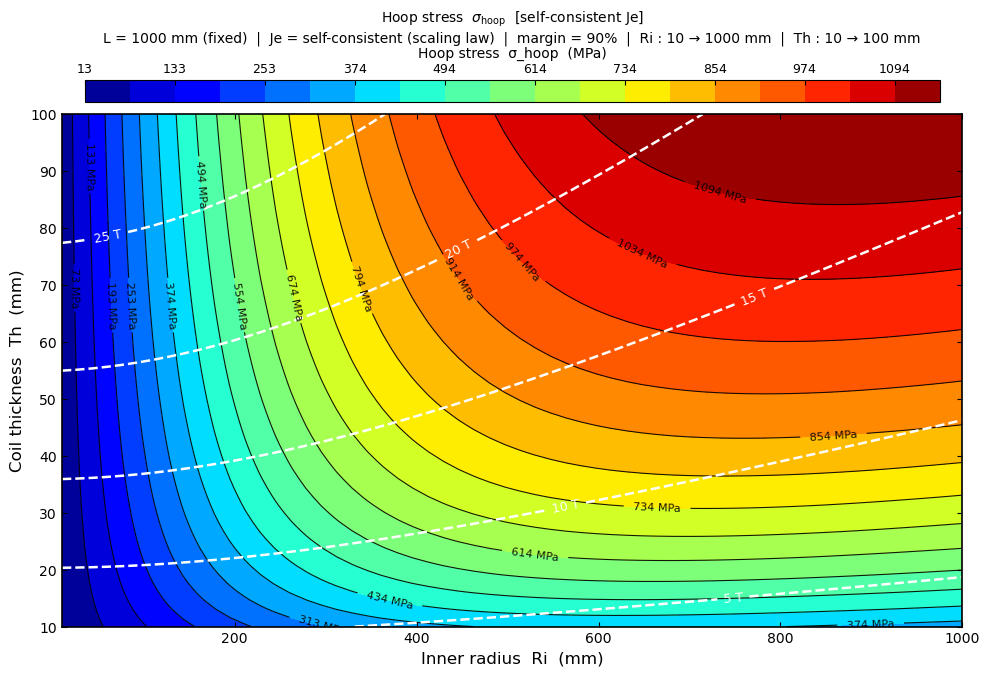

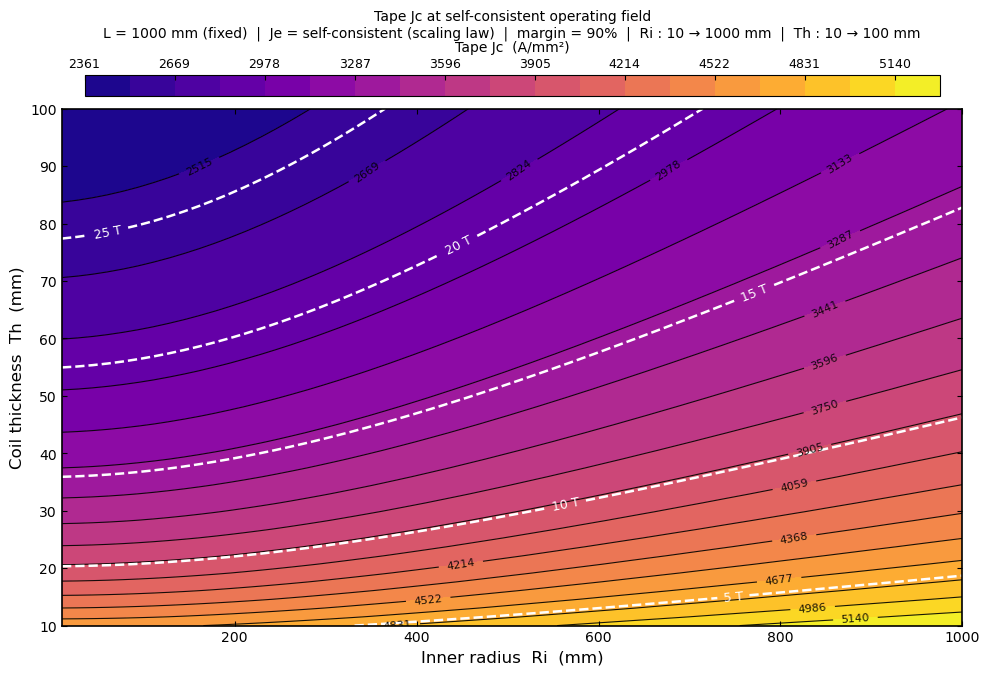

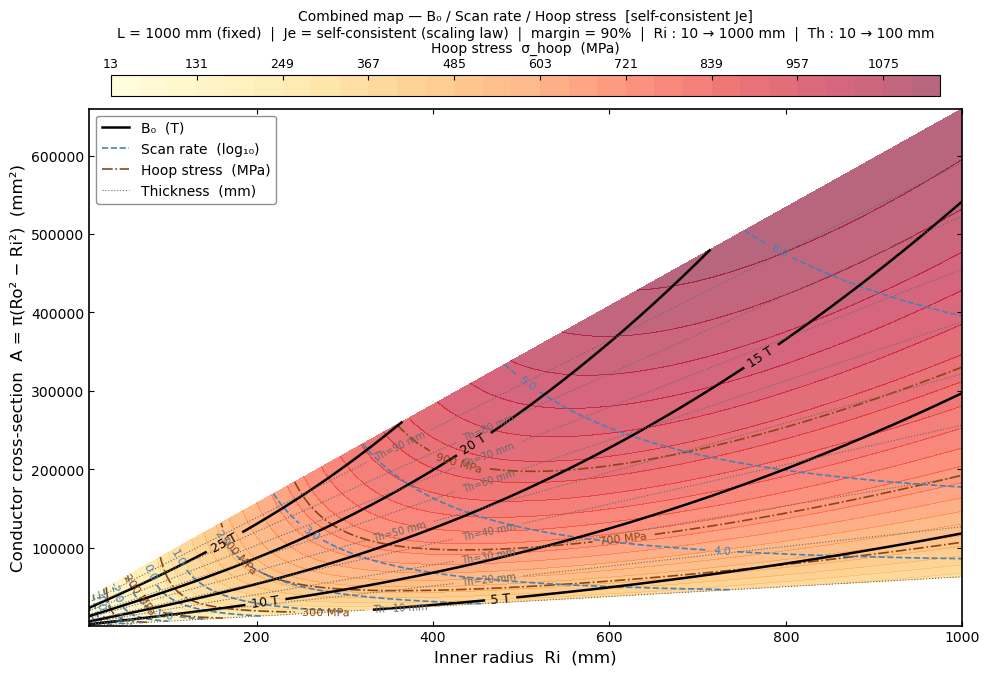

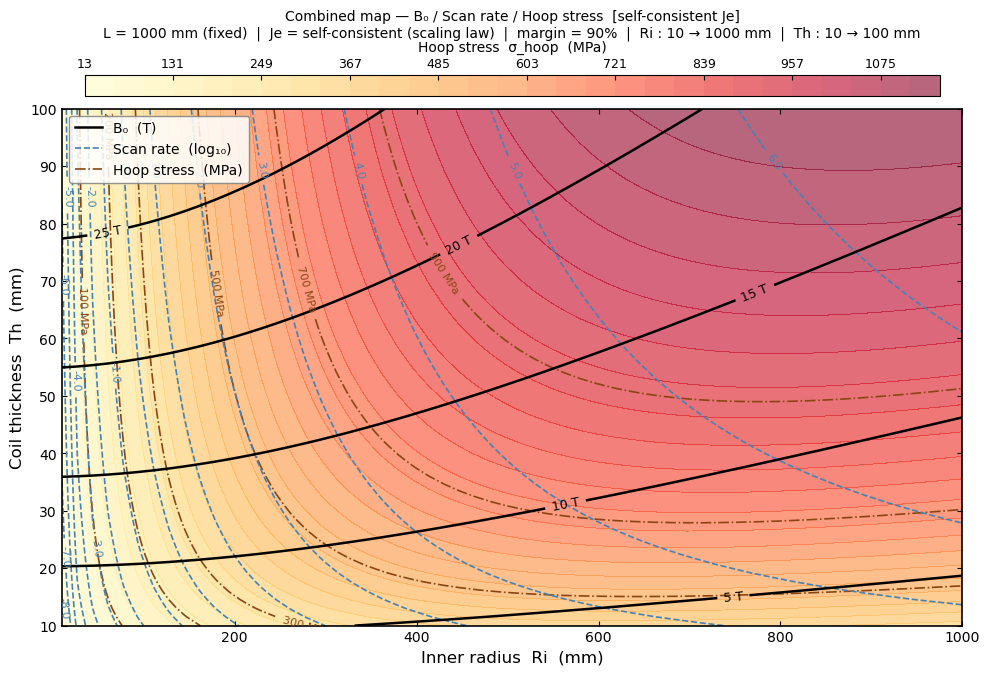

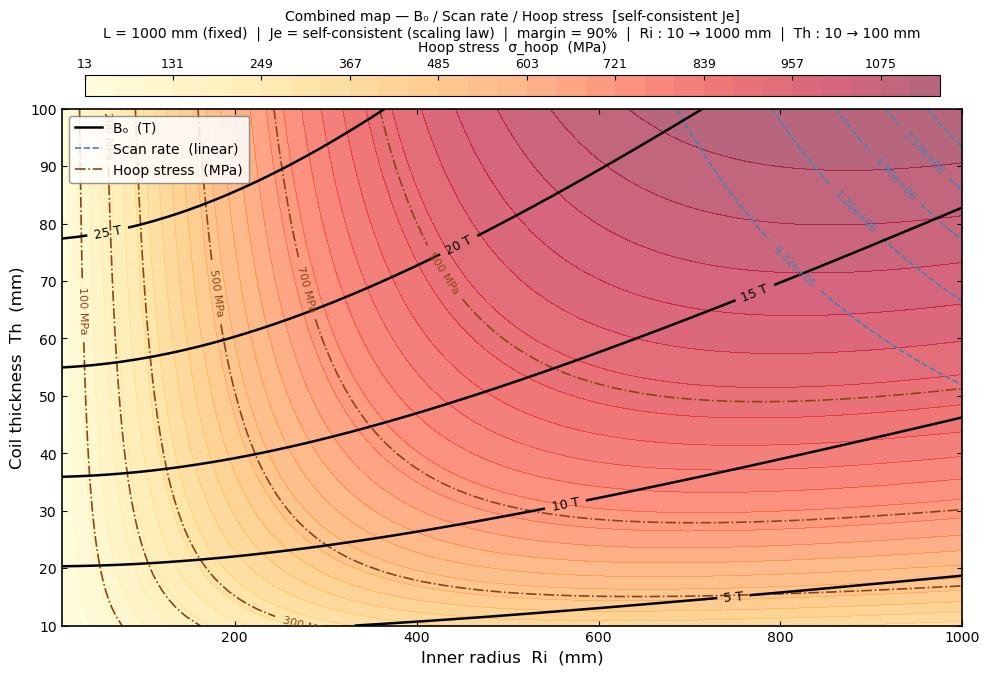

In [10]:
# %% [1] — Imports
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import importlib

import solenoid_lib
importlib.reload(solenoid_lib)

from solenoid_lib import (
    solenoid_length,
    theta_solenoid,
    w_tape_mm,
    t_tape_mm,
    mu0,
    margin,
    Ic_tape,
    Je_tape,
    solenoid_field_center,
    solenoid_field_profile,
    magnetic_energy,
    hoop_stress,
    solenoid_summary,
)


# %% [2] — Parameters
# ─────────────────────────────────────────────────────────────────────────────
max_iter    = 50       # [—]      max self-consistent iterations per cell
tol_rel     = 1e-4     # [—]      relative convergence tolerance on Je
je_init     = 500.0    # [A/mm²]  initial guess for Je (all cells)


# %% [3] — Build 2-D meshgrid  :  x = Ri (m),  y = Th (m)
# ─────────────────────────────────────────────────────────────────────────────
n_ri = 60
n_th = 60

ri_values_2d = np.linspace(0.010, 1.000, n_ri)   # m   10 mm → 1000 mm
th_values_2d = np.linspace(0.010, 0.1, n_th)   # m    10 mm →   100 mm

ri_grid2, th_grid2 = np.meshgrid(ri_values_2d, th_values_2d)
rf_grid2            = ri_grid2 + th_grid2
v_grid2             = np.pi * ri_grid2**2 * solenoid_length   # bore volume [m³]

# Output grids — initialised to NaN
b0_grid2        = np.full_like(ri_grid2, np.nan)   # [T]       central field
scan_grid2      = np.full_like(ri_grid2, np.nan)   # [—]       scan-rate figure of merit
stress_grid2    = np.full_like(ri_grid2, np.nan)   # [MPa]     hoop stress
j_crit_grid2    = np.full_like(ri_grid2, np.nan)   # [A/mm²]   tape Jc at operating field
je_max_grid2    = np.full_like(ri_grid2, np.nan)   # [A/mm²]   derated Je  = Jc*(1-margin)
je_sc_grid2     = np.full_like(ri_grid2, np.nan)   # [A/mm²]   self-consistent Je
margin_grid2    = np.full_like(ri_grid2, np.nan)   # [—]       load ratio Jc / Je_sc
converged_grid2 = np.zeros((n_th, n_ri), dtype=bool)  # convergence flag


# %% [4] — Self-consistent loop
# ─────────────────────────────────────────────────────────────────────────────
#
#   Physical fixed point:
#       Je  →  B0 = solenoid_field_center(Je)
#           →  Jc(B0)  from scaling law  (via Je_tape)
#           →  Je_new  = Jc(B0) * (1 – margin)
#   Iterate until |Je_new – Je| / Je < tol_rel
#
total = n_ri * n_th
done  = 0

for i in range(n_th):
    for j in range(n_ri):
        ri = ri_grid2[i, j]
        rf = rf_grid2[i, j]
        v  = v_grid2[i, j]

        try:
            # ── Self-consistent iteration ─────────────────────────────────
            je_mm2    = je_init
            converged = False

            for iteration in range(max_iter):
                je_si = je_mm2 * 1e6   # A/mm² → A/m²

                # Step 1 — field produced by the coil at the current Je
                b0 = solenoid_field_center(ri, rf, je_si, solenoid_length)

                # Step 2 — critical and derated Je at that field
                j_crit_mm2, je_max_mm2 = Je_tape(b0, theta_solenoid)
                # je_max_mm2 = Jc * (1 – margin)  [done inside Je_tape]

                # Step 3 — new operating Je is the derated critical value
                je_new_mm2 = je_max_mm2

                # Step 4 — convergence check
                rel_change = abs(je_new_mm2 - je_mm2) / (abs(je_mm2) + 1e-12)
                je_mm2     = je_new_mm2

                if rel_change < tol_rel:
                    converged = True
                    break

            # ── Final quantities at the converged Je ──────────────────────
            je_si       = je_mm2 * 1e6
            b0          = solenoid_field_center(ri, rf, je_si, solenoid_length)
            sigma_pa, _ = hoop_stress(ri, rf, je_si, solenoid_length)
            j_crit_mm2, je_max_mm2 = Je_tape(b0, theta_solenoid)
            load_ratio  = j_crit_mm2 / je_mm2   # ≈ 1/(1–margin) at convergence

            # ── Store results ─────────────────────────────────────────────
            b0_grid2[i, j]        = b0
            scan_grid2[i, j]      = (b0**2 * v**(5 / 3))**2
            stress_grid2[i, j]    = sigma_pa / 1e6
            j_crit_grid2[i, j]    = j_crit_mm2
            je_max_grid2[i, j]    = je_max_mm2
            je_sc_grid2[i, j]     = je_mm2
            margin_grid2[i, j]    = load_ratio
            converged_grid2[i, j] = converged

        except (ValueError, RuntimeError):
            pass

        done += 1

    print(f"  {done}/{total}  ({100*done/total:.0f}%)", end="\r")

print("\n2-D meshgrid computed.")

n_valid     = np.sum(np.isfinite(b0_grid2))
n_converged = np.sum(converged_grid2)
print(f"  Valid cells        : {n_valid} / {total}")
print(f"  Converged cells    : {n_converged} / {n_valid}")
print(f"  Ri                 : {np.nanmin(ri_grid2)*1e3:.1f}  –  {np.nanmax(ri_grid2)*1e3:.1f} mm")
print(f"  Th                 : {np.nanmin(th_grid2)*1e3:.1f}  –  {np.nanmax(th_grid2)*1e3:.1f} mm")
print(f"  B0 (self-consist.) : {np.nanmin(b0_grid2):.3f}  –  {np.nanmax(b0_grid2):.3f} T")
print(f"  Je (self-consist.) : {np.nanmin(je_sc_grid2):.2f}  –  {np.nanmax(je_sc_grid2):.2f} A/mm²")
print(f"  Je_crit            : {np.nanmin(j_crit_grid2):.2f}  –  {np.nanmax(j_crit_grid2):.2f} A/mm²")
print(f"  Je_max             : {np.nanmin(je_max_grid2):.2f}  –  {np.nanmax(je_max_grid2):.2f} A/mm²")
print(f"  Load ratio         : {np.nanmin(margin_grid2):.3f}  –  {np.nanmax(margin_grid2):.3f}")
print(f"  Stress             : {np.nanmin(stress_grid2):.1f}  –  {np.nanmax(stress_grid2):.1f} MPa")
print(f"  V_bore             : {np.nanmin(v_grid2)*1e6:.3e}  –  {np.nanmax(v_grid2)*1e6:.3e} cm³")


# %% [5] — Shared plot quantities
# ─────────────────────────────────────────────────────────────────────────────
x_data = ri_grid2 * 1e3   # mm
y_data = th_grid2 * 1e3   # mm

title_suffix = (
    f"L = {solenoid_length*1e3:.0f} mm (fixed)  |  "
    f"Je = self-consistent (scaling law)  |  "
    f"margin = {margin*100:.0f}%  |  "
    f"Ri : 10 → 1000 mm  |  Th : 10 → 100 mm"
)

b0_iso_levels = [1, 5, 10, 15, 20, 25, 30, 40]
b0_iso_lw     = 1.8
b0_iso_ls     = "--"


# %% [6] — Style helpers
# ─────────────────────────────────────────────────────────────────────────────

def _style_axes(ax):
    ax.tick_params(
        which="both",
        top=True, bottom=True, left=True, right=True,
        direction="in", labelsize=10,
    )
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)


def _add_b0_contours(ax, label_color="white"):
    b0_min = np.nanmin(b0_grid2)
    b0_max = np.nanmax(b0_grid2)
    levels = [lv for lv in b0_iso_levels if b0_min <= lv <= b0_max]
    if not levels:
        return
    cs = ax.contour(
        x_data, y_data, b0_grid2,
        levels=levels, colors=label_color,
        linewidths=b0_iso_lw, linestyles=b0_iso_ls,
    )
    ax.clabel(cs, fmt=lambda v: f"{v:.0f} T", fontsize=9,
              inline=True, inline_spacing=4, colors=label_color)


def _safe_levels(vmin, vmax, step=None, n=20):
    """Always return at least 2 monotonically increasing levels."""
    if step is not None:
        levels = np.arange(np.floor(vmin / step) * step,
                           vmax + step, step)
        levels = levels[(levels >= vmin) & (levels <= vmax + step)]
        if len(levels) >= 2:
            return levels
    if np.isclose(vmin, vmax):
        span = max(1.0, 0.01 * abs(vmin), 1e-6)
        return np.array([vmin - span, vmax + span])
    return np.linspace(vmin, vmax, n)


def _make_contour_plot(fig, ax,
                       z, levels, cmap,
                       label_fmt, cbar_label, title,
                       line_color="k", line_width=0.8,
                       label_fontsize=8):
    cf = ax.contourf(x_data, y_data, z, levels=levels, cmap=cmap)
    cs = ax.contour(x_data, y_data, z, levels=levels,
                    colors=line_color, linewidths=line_width, alpha=0.9)
    ax.clabel(cs, fmt=label_fmt, fontsize=label_fontsize,
              inline=True, colors=line_color)
    cbar = fig.colorbar(
        cf, ax=ax, orientation="horizontal", location="top",
        pad=0.02, aspect=40, shrink=0.95,
    )
    cbar.set_label(cbar_label, fontsize=10, labelpad=4)
    cbar.ax.tick_params(labelsize=9, direction="in")
    ax.set_title(title, fontsize=10, pad=52)
    _style_axes(ax)
    return cf, cs


def _set_mm_axes(ax):
    ax.set_xlabel("Inner radius  Ri  (mm)", fontsize=12)
    ax.set_ylabel("Coil thickness  Th  (mm)", fontsize=12)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f"))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f"))


# %% [7] — Plot 1 : Central field B0 (self-consistent)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
levels_b0 = _safe_levels(np.nanmin(b0_grid2), np.nanmax(b0_grid2), step=2.0)
_make_contour_plot(
    fig, ax,
    z=b0_grid2, levels=levels_b0, cmap="jet",
    label_fmt="%.0f T", cbar_label="Central field  B₀  (T)",
    title=f"Central field B₀  [self-consistent Je]\n{title_suffix}",
)
_add_b0_contours(ax, label_color="white")
_set_mm_axes(ax)
plt.tight_layout()
plt.savefig("contour_B0_sc.png", dpi=150, bbox_inches="tight")
plt.show()


# %% [8] — Plot 2 : Self-consistent Je
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
levels_je = _safe_levels(np.nanmin(je_sc_grid2), np.nanmax(je_sc_grid2), n=20)
_make_contour_plot(
    fig, ax,
    z=je_sc_grid2, levels=levels_je, cmap="plasma",
    label_fmt="%.0f", cbar_label="Self-consistent Je  (A/mm²)",
    title=f"Self-consistent operating Je\n{title_suffix}",
)
_add_b0_contours(ax, label_color="white")
_set_mm_axes(ax)
plt.tight_layout()
plt.savefig("contour_Je_sc.png", dpi=150, bbox_inches="tight")
plt.show()

# %% [9] — Plot 3 : Scan rate  (log₁₀)
# ─────────────────────────────────────────────────────────────────────────────
scan_log2 = np.log10(np.where(scan_grid2 > 0, scan_grid2, np.nan))
fig, ax = plt.subplots(figsize=(10, 7))
levels_sr = _safe_levels(np.nanmin(scan_log2), np.nanmax(scan_log2), n=20)
_make_contour_plot(
    fig, ax,
    z=scan_log2, levels=levels_sr, cmap="jet",
    label_fmt="%.1f",
    cbar_label="log₁₀(Scan rate)  [log₁₀((T²·m^(5/3))²)]",
    title=(
        r"Scan rate  $(B_0^2 \cdot V_{\rm bore}^{5/3})^2$"
        + f"  [self-consistent Je]\n{title_suffix}"
    ),
)
_add_b0_contours(ax, label_color="white")
_set_mm_axes(ax)
plt.tight_layout()
plt.savefig("contour_scanrate_sc.png", dpi=150, bbox_inches="tight")
plt.show()


# %% [10] — Plot 4 : Hoop stress
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
levels_st = _safe_levels(np.nanmin(stress_grid2), np.nanmax(stress_grid2), n=20)
_make_contour_plot(
    fig, ax,
    z=stress_grid2, levels=levels_st, cmap="jet",
    label_fmt="%.0f MPa", cbar_label="Hoop stress  σ_hoop  (MPa)",
    title=(
        r"Hoop stress  $\sigma_{\rm hoop}$"
        + f"  [self-consistent Je]\n{title_suffix}"
    ),
)
_add_b0_contours(ax, label_color="white")
_set_mm_axes(ax)
plt.tight_layout()
plt.savefig("contour_stress_sc.png", dpi=150, bbox_inches="tight")
plt.show()


# %% [11] — Plot 5 : Tape Jc at operating field
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
levels_jc = _safe_levels(np.nanmin(j_crit_grid2), np.nanmax(j_crit_grid2), n=20)
_make_contour_plot(
    fig, ax,
    z=j_crit_grid2, levels=levels_jc, cmap="plasma",
    label_fmt="%.0f", cbar_label="Tape Jc  (A/mm²)",
    title=(
        f"Tape Jc at self-consistent operating field\n{title_suffix}"
    ),
)
_add_b0_contours(ax, label_color="white")
_set_mm_axes(ax)
plt.tight_layout()
plt.savefig("contour_je_crit_sc.png", dpi=150, bbox_inches="tight")
plt.show()

# %% [13] — Combined plot : B0 + scan rate + hoop stress iso-lines  (Ri vs A)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

# ── Axes data ─────────────────────────────────────────────────────────────────
x_data_comb = ri_grid2 * 1e3                              # [mm]
y_data_comb = np.pi * (rf_grid2**2 - ri_grid2**2) * 1e6  # [mm²]  π*(Ro²-Ri²)

# ── Background : hoop stress filled contour ───────────────────────────────────
levels_st_comb = _safe_levels(np.nanmin(stress_grid2), np.nanmax(stress_grid2), n=30)
cf = ax.contourf(x_data_comb, y_data_comb, stress_grid2,
                 levels=levels_st_comb, cmap="YlOrRd", alpha=0.6)
cbar = fig.colorbar(
    cf, ax=ax, orientation="horizontal", location="top",
    pad=0.02, aspect=40, shrink=0.95,
)
cbar.set_label("Hoop stress  σ_hoop  (MPa)", fontsize=10, labelpad=4)
cbar.ax.tick_params(labelsize=9, direction="in")

# ── Hoop stress iso-lines ─────────────────────────────────────────────────────
stress_iso_levels = [100, 200, 300, 500, 700, 900, 1200, 1500]
stress_iso_levels = [lv for lv in stress_iso_levels
                     if np.nanmin(stress_grid2) <= lv <= np.nanmax(stress_grid2)]
if stress_iso_levels:
    cs_st = ax.contour(x_data_comb, y_data_comb, stress_grid2,
                       levels=stress_iso_levels,
                       colors="saddlebrown", linewidths=1.2, linestyles="-.")
    ax.clabel(cs_st, fmt=lambda v: f"{v:.0f} MPa", fontsize=8,
              inline=True, inline_spacing=4, colors="saddlebrown")

# ── Scan rate iso-lines ───────────────────────────────────────────────────────
scan_log_comb   = np.log10(np.where(scan_grid2 > 0, scan_grid2, np.nan))
scan_iso_levels = np.arange(np.floor(np.nanmin(scan_log_comb)),
                             np.nanmax(scan_log_comb) + 1, 1)
if len(scan_iso_levels) >= 2:
    cs_sr = ax.contour(x_data_comb, y_data_comb, scan_log_comb,
                       levels=scan_iso_levels,
                       colors="steelblue", linewidths=1.2, linestyles="--")
    ax.clabel(cs_sr, fmt=lambda v: f"{v:.1f}", fontsize=8,
              inline=True, inline_spacing=4, colors="steelblue")

# ── B0 iso-lines ──────────────────────────────────────────────────────────────
b0_min_comb    = np.nanmin(b0_grid2)
b0_max_comb    = np.nanmax(b0_grid2)
b0_levels_comb = [lv for lv in b0_iso_levels
                  if b0_min_comb <= lv <= b0_max_comb]
if b0_levels_comb:
    cs_b0 = ax.contour(x_data_comb, y_data_comb, b0_grid2,
                       levels=b0_levels_comb,
                       colors="black", linewidths=1.8, linestyles="-")
    ax.clabel(cs_b0, fmt=lambda v: f"{v:.0f} T", fontsize=9,
              inline=True, inline_spacing=4, colors="black")

# ── Thickness iso-lines (orientation guide) ───────────────────────────────────
th_iso_mm   = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
th_iso_data = th_grid2 * 1e3    # [mm]
th_iso_plot = [lv for lv in th_iso_mm
               if np.nanmin(th_iso_data) <= lv <= np.nanmax(th_iso_data)]
if th_iso_plot:
    cs_th = ax.contour(x_data_comb, y_data_comb, th_iso_data,
                       levels=th_iso_plot,
                       colors="dimgrey", linewidths=0.8, linestyles=":")
    ax.clabel(cs_th, fmt=lambda v: f"Th={v:.0f} mm", fontsize=7,
              inline=True, inline_spacing=4, colors="dimgrey")

# ── Legend proxies ────────────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], color="black",       lw=1.8, ls="-",  label="B₀  (T)"),
    Line2D([0], [0], color="steelblue",   lw=1.2, ls="--", label="Scan rate  (log₁₀)"),
    Line2D([0], [0], color="saddlebrown", lw=1.2, ls="-.", label="Hoop stress  (MPa)"),
    Line2D([0], [0], color="dimgrey",     lw=0.8, ls=":",  label="Thickness  (mm)"),
]
ax.legend(handles=legend_handles, fontsize=10, loc="upper left",
          framealpha=0.85, edgecolor="grey")

# ── Labels & formatting ───────────────────────────────────────────────────────
ax.set_title(
    f"Combined map — B₀ / Scan rate / Hoop stress  [self-consistent Je]\n{title_suffix}",
    fontsize=10, pad=52,
)
ax.set_xlabel("Inner radius  Ri  (mm)", fontsize=12)
ax.set_ylabel("Conductor cross-section  A = π(Ro² − Ri²)  (mm²)", fontsize=12)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f"))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f"))
_style_axes(ax)
plt.tight_layout()
plt.savefig("contour_combined_area_sc.png", dpi=150, bbox_inches="tight")
plt.show()




# %% [14] — Combined plot : B0 + scan rate + hoop stress iso-lines  (Ri vs Th)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

# ── Background : hoop stress filled contour ───────────────────────────────────
levels_st_comb = _safe_levels(np.nanmin(stress_grid2), np.nanmax(stress_grid2), n=30)
cf = ax.contourf(x_data, y_data, stress_grid2,
                 levels=levels_st_comb, cmap="YlOrRd", alpha=0.6)
cbar = fig.colorbar(
    cf, ax=ax, orientation="horizontal", location="top",
    pad=0.02, aspect=40, shrink=0.95,
)
cbar.set_label("Hoop stress  σ_hoop  (MPa)", fontsize=10, labelpad=4)
cbar.ax.tick_params(labelsize=9, direction="in")

# ── Hoop stress iso-lines ─────────────────────────────────────────────────────
stress_iso_levels = [100, 200, 300, 500, 700, 900, 1200, 1500]
stress_iso_levels = [lv for lv in stress_iso_levels
                     if np.nanmin(stress_grid2) <= lv <= np.nanmax(stress_grid2)]
if stress_iso_levels:
    cs_st = ax.contour(x_data, y_data, stress_grid2,
                       levels=stress_iso_levels,
                       colors="saddlebrown", linewidths=1.2, linestyles="-.")
    ax.clabel(cs_st, fmt=lambda v: f"{v:.0f} MPa", fontsize=8,
              inline=True, inline_spacing=4, colors="saddlebrown")

# ── Scan rate iso-lines ───────────────────────────────────────────────────────
scan_log_comb   = np.log10(np.where(scan_grid2 > 0, scan_grid2, np.nan))
scan_iso_levels = np.arange(np.floor(np.nanmin(scan_log_comb)),
                             np.nanmax(scan_log_comb) + 1, 1)
if len(scan_iso_levels) >= 2:
    cs_sr = ax.contour(x_data, y_data, scan_log_comb,
                       levels=scan_iso_levels,
                       colors="steelblue", linewidths=1.2, linestyles="--")
    ax.clabel(cs_sr, fmt=lambda v: f"{v:.1f}", fontsize=8,
              inline=True, inline_spacing=4, colors="steelblue")

# ── B0 iso-lines ──────────────────────────────────────────────────────────────
b0_min_comb    = np.nanmin(b0_grid2)
b0_max_comb    = np.nanmax(b0_grid2)
b0_levels_comb = [lv for lv in b0_iso_levels
                  if b0_min_comb <= lv <= b0_max_comb]
if b0_levels_comb:
    cs_b0 = ax.contour(x_data, y_data, b0_grid2,
                       levels=b0_levels_comb,
                       colors="black", linewidths=1.8, linestyles="-")
    ax.clabel(cs_b0, fmt=lambda v: f"{v:.0f} T", fontsize=9,
              inline=True, inline_spacing=4, colors="black")

# ── Legend proxies ────────────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], color="black",       lw=1.8, ls="-",  label="B₀  (T)"),
    Line2D([0], [0], color="steelblue",   lw=1.2, ls="--", label="Scan rate  (log₁₀)"),
    Line2D([0], [0], color="saddlebrown", lw=1.2, ls="-.", label="Hoop stress  (MPa)"),
]
ax.legend(handles=legend_handles, fontsize=10, loc="upper left",
          framealpha=0.85, edgecolor="grey")

# ── Labels & formatting ───────────────────────────────────────────────────────
ax.set_title(
    f"Combined map — B₀ / Scan rate / Hoop stress  [self-consistent Je]\n{title_suffix}",
    fontsize=10, pad=52,
)
_set_mm_axes(ax)
_style_axes(ax)
plt.tight_layout()
plt.savefig("contour_combined_sc.png", dpi=150, bbox_inches="tight")
plt.show()


# %% [14] — Combined plot : B0 + scan rate + hoop stress iso-lines  (Ri vs Th)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

# ── Background : hoop stress filled contour ───────────────────────────────────
levels_st_comb = _safe_levels(np.nanmin(stress_grid2), np.nanmax(stress_grid2), n=30)
cf = ax.contourf(x_data, y_data, stress_grid2,
                 levels=levels_st_comb, cmap="YlOrRd", alpha=0.6)
cbar = fig.colorbar(
    cf, ax=ax, orientation="horizontal", location="top",
    pad=0.02, aspect=40, shrink=0.95,
)
cbar.set_label("Hoop stress  σ_hoop  (MPa)", fontsize=10, labelpad=4)
cbar.ax.tick_params(labelsize=9, direction="in")

# ── Hoop stress iso-lines ─────────────────────────────────────────────────────
stress_iso_levels = [100, 200, 300, 500, 700, 900, 1200, 1500]
stress_iso_levels = [lv for lv in stress_iso_levels
                     if np.nanmin(stress_grid2) <= lv <= np.nanmax(stress_grid2)]
if stress_iso_levels:
    cs_st = ax.contour(x_data, y_data, stress_grid2,
                       levels=stress_iso_levels,
                       colors="saddlebrown", linewidths=1.2, linestyles="-.")
    ax.clabel(cs_st, fmt=lambda v: f"{v:.0f} MPa", fontsize=8,
              inline=True, inline_spacing=4, colors="saddlebrown")

# ── Scan rate iso-lines  (LINEAR, no log scale) ───────────────────────────────
scan_lin_comb = np.where(scan_grid2 > 0, scan_grid2, np.nan)
sr_min = np.nanmin(scan_lin_comb)
sr_max = np.nanmax(scan_lin_comb)
# Evenly spaced linear levels across the data range.
scan_iso_levels = np.linspace(sr_min, sr_max, 7)
# Drop the extreme endpoints so labels don't sit on the plot edges.
scan_iso_levels = scan_iso_levels[1:-1]
if len(scan_iso_levels) >= 1:
    cs_sr = ax.contour(x_data, y_data, scan_lin_comb,
                       levels=scan_iso_levels,
                       colors="steelblue", linewidths=1.2, linestyles="--")
    ax.clabel(cs_sr, fmt=lambda v: f"{v:.2e}", fontsize=8,
              inline=True, inline_spacing=4, colors="steelblue")

# ── B0 iso-lines ──────────────────────────────────────────────────────────────
b0_min_comb    = np.nanmin(b0_grid2)
b0_max_comb    = np.nanmax(b0_grid2)
b0_levels_comb = [lv for lv in b0_iso_levels
                  if b0_min_comb <= lv <= b0_max_comb]
if b0_levels_comb:
    cs_b0 = ax.contour(x_data, y_data, b0_grid2,
                       levels=b0_levels_comb,
                       colors="black", linewidths=1.8, linestyles="-")
    ax.clabel(cs_b0, fmt=lambda v: f"{v:.0f} T", fontsize=9,
              inline=True, inline_spacing=4, colors="black")

# ── Legend proxies ────────────────────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], color="black",       lw=1.8, ls="-",  label="B₀  (T)"),
    Line2D([0], [0], color="steelblue",   lw=1.2, ls="--", label="Scan rate  (linear)"),
    Line2D([0], [0], color="saddlebrown", lw=1.2, ls="-.", label="Hoop stress  (MPa)"),
]
ax.legend(handles=legend_handles, fontsize=10, loc="upper left",
          framealpha=0.85, edgecolor="grey")

# ── Labels & formatting ───────────────────────────────────────────────────────
ax.set_title(
    f"Combined map — B₀ / Scan rate / Hoop stress  [self-consistent Je]\n{title_suffix}",
    fontsize=10, pad=52,
)
_set_mm_axes(ax)
_style_axes(ax)
plt.tight_layout()
plt.savefig("contour_combined_sc.png", dpi=150, bbox_inches="tight")
plt.show()







